# 01 · Diagnóstico dos dados

**Objetivo:** conhecer as bases antes de modelar e achar as armadilhas que derrubariam o modelo na Base B.

1. Inadimplência por safra
2. Poder de cada variável sozinha (AUC univariado), incluindo a variável que "vaza" o futuro
3. Valores ausentes que carregam risco
4. Categorias
5. Viés de seleção: a Base C é diferente da A
6. Conferência dos parâmetros de EAD e LGD

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from autocred import dados, perda
from autocred.avaliacao import auc

pd.set_option("display.float_format", "{:.4f}".format)
A = dados.carregar_base("A")
B = dados.carregar_base("B")
C = dados.carregar_base("C")
A["ano"] = dados.ano(A)
print("Base A:", A.shape, "| Base B:", B.shape, "| Base C:", C.shape)

Base A: (10000, 29) | Base B: (3000, 23) | Base C: (5000, 21)


## 1. Inadimplência por safra

A **PD 90/12 observada** é a média do alvo `default_90_12`: a fração de contratos que chegaram a 90 dias
de atraso nos 12 meses após a concessão. Se ela muda de um ano para outro, o passado não é igual ao futuro.
Por isso validamos **por tempo** (treina no passado, testa no ano seguinte) e nunca com split aleatório.

,contratos,inadimplencia
ano,,
2022,3380,0.0867
2023,3290,0.0894
2024,3330,0.0718


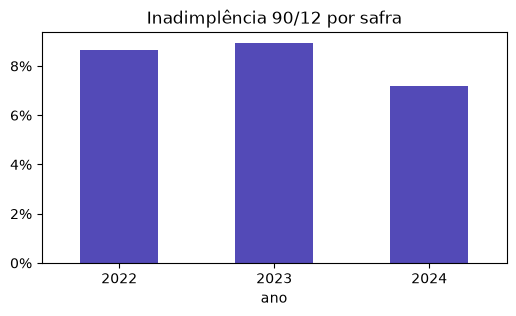

In [2]:
por_ano = A.groupby("ano")[dados.ALVO].agg(contratos="size", inadimplencia="mean")
display(por_ano)
ax = por_ano["inadimplencia"].plot.bar(color="#534AB7", figsize=(6, 3), title="Inadimplência 90/12 por safra", rot=0)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
plt.show()

## 2. Quanto cada variável ordena o risco sozinha

O **AUC** mede a ordenação: é a chance de um inadimplente sorteado ter valor "mais arriscado" que um adimplente
sorteado. 0,5 = moeda; 1,0 = perfeito. Aqui cada variável é usada sozinha, sem modelo.

In [3]:
candidatas = dados.NUMERICAS + ["taxa_juros_am", "qtd_parcelas_em_atraso_12m"]
y = A[dados.ALVO].to_numpy()
linhas = []
for coluna in candidatas:
    presente = A[coluna].notna().to_numpy()
    a = auc(y[presente], A.loc[presente, coluna])
    linhas.append({"variavel": coluna, "auc": max(a, 1 - a), "direcao": "sobe o risco" if a >= 0.5 else "desce o risco"})
univariado = pd.DataFrame(linhas).sort_values("auc", ascending=False).reset_index(drop=True)
display(univariado)

,variavel,auc,direcao
0,qtd_parcelas_em_atraso_12m,0.9644,sobe o risco
1,score_bureau,0.6116,desce o risco
2,renda_mensal_declarada,0.5985,desce o risco
3,idade_cliente,0.5761,desce o risco
4,qtd_restricoes_ativas,0.5759,sobe o risco
5,prazo_meses,0.5708,sobe o risco
6,parcela_mensal,0.5640,desce o risco
7,valor_bem,0.5584,desce o risco
8,comprometimento_renda,0.5581,sobe o risco
9,valor_entrada,0.5570,desce o risco


### A variável que vaza o futuro

`qtd_parcelas_em_atraso_12m` tem AUC perto de **0,96** sozinha. Parece mágica, mas é apurada **depois** da
concessão: conta as parcelas atrasadas nos 12 meses seguintes. Na hora de aprovar o crédito ela não existe.
Nas Bases B e C ela está **zerada**. Um modelo que dependesse dela veria todo mundo igual e erraria a ordenação.
Por isso ela está na lista `dados.PROIBIDAS`, e o Pipeline se recusa a usá-la.

In [4]:
display(pd.DataFrame({
    "Base A": A["qtd_parcelas_em_atraso_12m"].describe(),
    "Base B": B["qtd_parcelas_em_atraso_12m"].describe(),
    "Base C": C["qtd_parcelas_em_atraso_12m"].describe(),
}))
assert (B["qtd_parcelas_em_atraso_12m"] == 0).all() and (C["qtd_parcelas_em_atraso_12m"] == 0).all()

,Base A,Base B,Base C
count,10000.0000,3000.0000,5000.0000
mean,0.9029,0.0000,0.0000
std,1.9294,0.0000,0.0000
min,0.0000,0.0000,0.0000
25%,0.0000,0.0000,0.0000
50%,0.0000,0.0000,0.0000
75%,1.0000,0.0000,0.0000
max,12.0000,0.0000,0.0000


Fora a variável proibida, a melhor ordenação individual é a do `score_bureau` (≈ 0,61). O sinal de cada
variável é fraco: o ganho vai vir da **combinação**, que é o trabalho do modelo.

## 3. Ausentes que carregam risco

Um valor em branco não é só "falta de dado". Quem não tem histórico no bureau, por exemplo, pode ser mais
arriscado. Por isso criamos um indicador `ausente_<coluna>` antes de preencher o valor.

In [5]:
ausentes = pd.DataFrame({
    "pct_ausente": A[dados.COM_AUSENTES].isna().mean(),
    "inad_quando_ausente": [A.loc[A[c].isna(), dados.ALVO].mean() for c in dados.COM_AUSENTES],
    "inad_quando_presente": [A.loc[A[c].notna(), dados.ALVO].mean() for c in dados.COM_AUSENTES],
}, index=dados.COM_AUSENTES)
display(ausentes)

,pct_ausente,inad_quando_ausente,inad_quando_presente
score_bureau,0.0327,0.1193,0.0814
renda_mensal_declarada,0.0770,0.0896,0.0820
tempo_emprego_meses,0.1207,0.0845,0.0823


## 4. Categorias

In [6]:
for coluna in dados.CATEGORICAS:
    display(A.groupby(coluna)[dados.ALVO].agg(contratos="size", inadimplencia="mean").sort_values("inadimplencia"))

,contratos,inadimplencia
canal_originacao,,
Concessionária,4093,0.0733
Digital,1962,0.0810
Revenda multimarca,2572,0.0910
Correspondente bancário,1373,0.0969


,contratos,inadimplencia
ocupacao,,
Servidor público,1149,0.0688
Empresário,909,0.0726
CLT,5149,0.0742
Aposentado,551,0.0817
Autônomo,2242,0.1133


,contratos,inadimplencia
tipo_residencia,,
Própria,3518,0.0748
Familiar,1652,0.0751
Financiada,1907,0.0813
Alugada,2923,0.0972


,contratos,inadimplencia
possui_avalista,,
Não,8401,0.0789
Sim,1599,0.1019


## 5. Viés de seleção: a Base C não é igual à A

As Bases A e B só têm clientes **aprovados** pela política antiga. A Base C tem todo mundo que pediu crédito,
inclusive perfis que eram recusados. O modelo nunca viu esses perfis, então a PD deles é uma **extrapolação**.
Este é o problema clássico da **inferência de rejeitados**.

,Base A,Base B,Base C
score_bureau,645.5196,646.2373,549.4823
qtd_restricoes_ativas,0.6251,0.6180,1.6952
qtd_consultas_bureau_3m,1.4975,1.5193,1.9872
renda_mensal_declarada,6386.5248,6588.6084,5214.3530
idade_veiculo_anos,4.0373,3.9807,4.4882


score_bureau mínimo na Base A   460.0000
restrições máximas na Base A      2.0000
LTV máximo na Base A              0.9500
dtype: float64

Propostas da Base C fora do perfil histórico: 39.5%


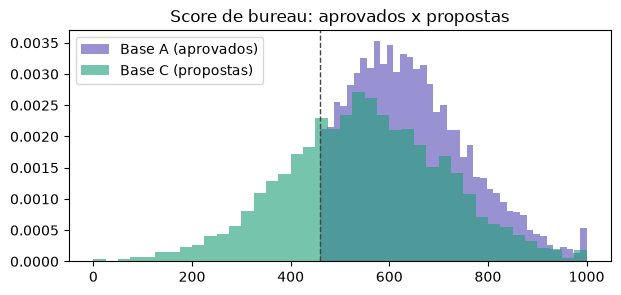

In [7]:
comparar = ["score_bureau", "qtd_restricoes_ativas", "qtd_consultas_bureau_3m", "renda_mensal_declarada", "idade_veiculo_anos"]
display(pd.DataFrame({"Base A": A[comparar].mean(), "Base B": B[comparar].mean(), "Base C": C[comparar].mean()}))
display(pd.Series({
    "score_bureau mínimo na Base A": A["score_bureau"].min(),
    "restrições máximas na Base A": A["qtd_restricoes_ativas"].max(),
    "LTV máximo na Base A": A["ltv"].max(),
}))
fora = (C["score_bureau"] < 460) | (C["qtd_restricoes_ativas"] > 2) | (C["ltv_desejado"] > 0.95)
print(f"Propostas da Base C fora do perfil histórico: {fora.mean():.1%}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(A["score_bureau"].dropna(), bins=40, alpha=0.6, density=True, label="Base A (aprovados)", color="#534AB7")
ax.hist(C["score_bureau"].dropna(), bins=40, alpha=0.6, density=True, label="Base C (propostas)", color="#1D9E75")
ax.axvline(460, color="#444441", linestyle="--", linewidth=1)
ax.set_title("Score de bureau: aprovados x propostas")
ax.legend()
plt.show()

## 6. Conferência dos parâmetros de EAD e LGD

O enunciado diz que as tabelas saem dos valores realizados da Base A. Conferimos, e descobrimos a convenção
das faixas de LTV: **fechadas à esquerda**. Um LTV de exatamente 60% cai em "60% a 70%".

In [8]:
tab = perda.carregar_tabelas()
d = A[A[dados.ALVO] == 1].copy()
d["f_ltv"] = perda.faixa_ltv(d["ltv"])
d["f_idade"] = perda.faixa_idade(d["idade_veiculo_anos"])
fator_real = (d["ead_realizado"] / d["valor_financiado"]).groupby([d["prazo_meses"], d["f_ltv"]]).mean().unstack()
lgd_real = d["lgd_realizado"].groupby([d["f_idade"], d["f_ltv"]]).mean().unstack()
dif_ead = np.abs(fator_real.to_numpy() - tab.fator_ead).max()
dif_lgd = np.abs(lgd_real.to_numpy() - tab.lgd).max()
print(f"Maior diferença entre realizado e tabela | EAD: {dif_ead:.4f} | LGD: {dif_lgd:.4f}")

Maior diferença entre realizado e tabela | EAD: 0.0005 | LGD: 0.0005


## Conclusões que viram regra no modelo

| Achado | Decisão |
|---|---|
| `qtd_parcelas_em_atraso_12m` vaza o futuro | proibida (trava no código) |
| Inadimplência muda por safra | validação out-of-time: J1 (2022→2023) e J2 (2022–23→2024) |
| Ausência de bureau/renda/emprego carrega risco | indicadores `ausente_*` dentro do Pipeline |
| Sinal individual fraco (melhor AUC ≈ 0,61) | torneio de modelos que combinam variáveis |
| ~40% da Base C fora do perfil histórico | alerta para a política e indicador `fora_perfil_historico` |
| Tabelas de EAD/LGD conferem com a Base A | usamos as tabelas com faixas fechadas à esquerda |